test with a 27pF bonded on the DUT position to test the bridge, R_ref = 27 kOhm

In [1]:
from impedance_bridge_analysis.load_data import LoadData, get_parameter_snapshot_value
from impedance_bridge_analysis.plotting import Plotter

from impedance_bridge_analysis.calculation import bridge_calculation


import numpy as np
import matplotlib.pyplot as plt

%matplotlib ipympl

In [2]:
plotr = Plotter(theme="presentation")
base_path = r"C:\Users\s.schreibing\Documents\qimchi_data\impedance_bridge\capacitor\01"

plot the 2d sweep of reference amplitude voltage and phase difference

In [3]:
experiment_name = r"\lockin_amplitude_ref and phase sweep - V_dut = -0.0 V"
id = 6

loader = LoadData(data_path = base_path + experiment_name)
data = loader.load_zarr(run_id=id)

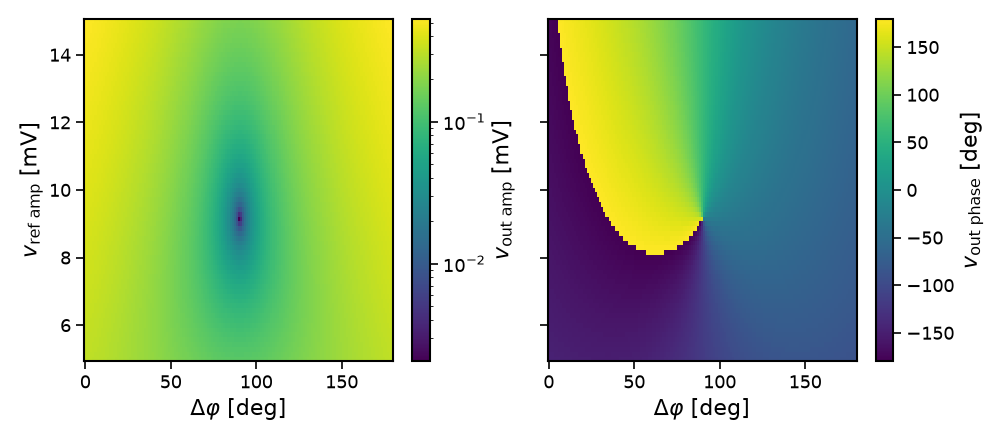

In [4]:
plotr.lockin_ref_phase_sweep(data, size_factor=1.6, balance_point=False, log_scale=True, save_path=rf"\plots\lockin_ref_phase_sweep_{id}_log.png")
#plotr.lockin_ref_phase_sweep(data, size_factor=1.6, balance_point=True, log_scale=False, save_path=rf"\plots\lockin_ref_phase_sweep_{id}.png")

Do lockin frequency sweep

In [5]:
experiment_name = r"\Lockin frequency sweep"
id = 3

loader = LoadData(data_path = base_path + experiment_name)
data_f_sweep = loader.load_zarr(run_id=id)

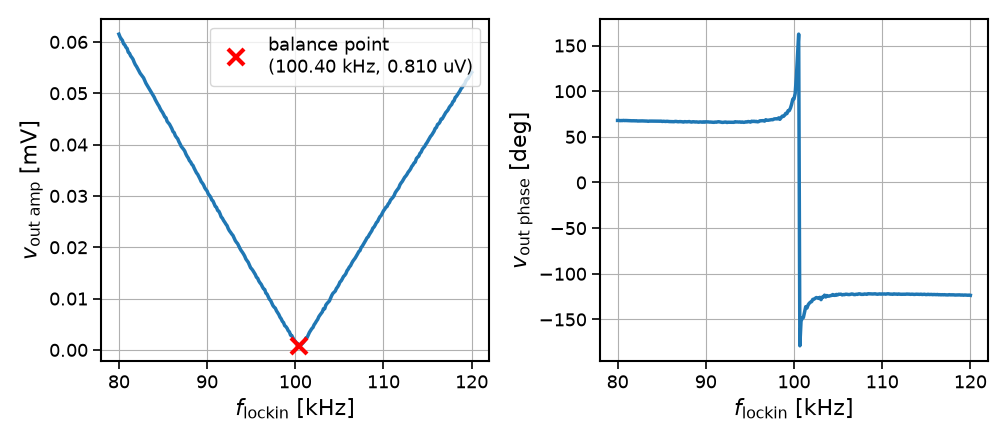

In [6]:
plotr.lockin_frequency_sweep(data_f_sweep, size_factor=1.6, balance_point=True, save_path=rf"\plots\lockin_frequency_sweep_{id}.png")

calculate capacity

In [7]:
R_ref = 27e3

calc = bridge_calculation(R_ref)

In [8]:
C = calc.calculate_capacitance(data_f_sweep)

print(f"Capacitance: {C*1e12:.5f} pF")

Capacitance: 27.01075 pF


In [9]:
Z_dut = calc.calculate_impedance(data)

print(f"Impedance: {Z_dut:.2f} Ohm")

Impedance: -257.70-59061.04j Ohm


Do a measurement where you vary the lockin_amp_dut and do frequency_sweep each time

In [10]:
experiment_name = r"\Lockin frequency sweep - vary dut amp"

id_list = [1, 2, 3, 4, 5, 6, 7]

C = []
dut_amp = []

for id in id_list:

    loader = LoadData(data_path = base_path + experiment_name)
    data_f_sweep = loader.load_zarr(run_id=id)

    C.append(calc.calculate_capacitance(data_f_sweep))
    dut_amp.append(get_parameter_snapshot_value(data_f_sweep, "lockin_amplitude_dut"))

print(np.array(C)*1e12)
print(f"Capacitance: ({np.mean(C)*1e12:.3f} +- {np.std(C, ddof=1)*1e12:.3f}) pF")

[27.01436513 27.02974321 26.96112845 26.96777346 27.03846508 26.91368531
 26.97815296]
Capacitance: (26.986 +- 0.044) pF


Do a measurement where you do 2d v_ref_amp and phase_diff sweeps for five different v_dut_amp voltages

In [11]:
experiment_name = r"\lockin_amplitude_ref and phase sweep - V_dut = 0 V - vary dut amp"

id_list = [1, 2, 3, 4, 5]

C = []
dut_amp = []

for id in id_list:

    loader = LoadData(data_path = base_path + experiment_name)
    data = loader.load_zarr(run_id=id)

    Z_dut = calc.calculate_impedance(data)
    f_lockin = get_parameter_snapshot_value(data, "lockin_frequency")

    print(f"Impedance: {Z_dut:.2f} Ohm")

    C.append(- 1 / (2 * np.pi * f_lockin * np.imag(Z_dut)))
    dut_amp.append(get_parameter_snapshot_value(data_f_sweep, "lockin_amplitude_dut"))

print(np.array(C)*1e12)
print(f"Capacitance: ({np.mean(C)*1e12:.3f} +- {np.std(C, ddof=1)*1e12:.3f}) pF")

Impedance: 540.15-58800.47j Ohm
Impedance: 538.77-58650.32j Ohm
Impedance: 542.53-59059.11j Ohm
Impedance: 537.96-58561.24j Ohm
Impedance: 543.86-59204.55j Ohm
[27.06695075 27.13624648 26.94841532 27.1775244  26.88221514]
Capacitance: (27.042 +- 0.125) pF
